<a href="https://colab.research.google.com/github/Pradeep-1503/House-price-prediction/blob/House-price-prediction/Untitled11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Admission_Predict.csv.csv to Admission_Predict.csv (2).csv
   serial_no.  gre_score  toefl_score  university_rating  sop  lor  cgpa  \
0           1        337          118                  4  4.5  4.5  9.65   
1           2        324          107                  4  4.0  4.5  8.87   
2           3        316          104                  3  3.0  3.5  8.00   
3           4        322          110                  3  3.5  2.5  8.67   
4           5        314          103                  2  2.0  3.0  8.21   

   research  chance_of_admit  admitted  
0         1                1         1  
1         1                1         1  
2         1                0         0  
3         1                1         1  
4         0                0         0  


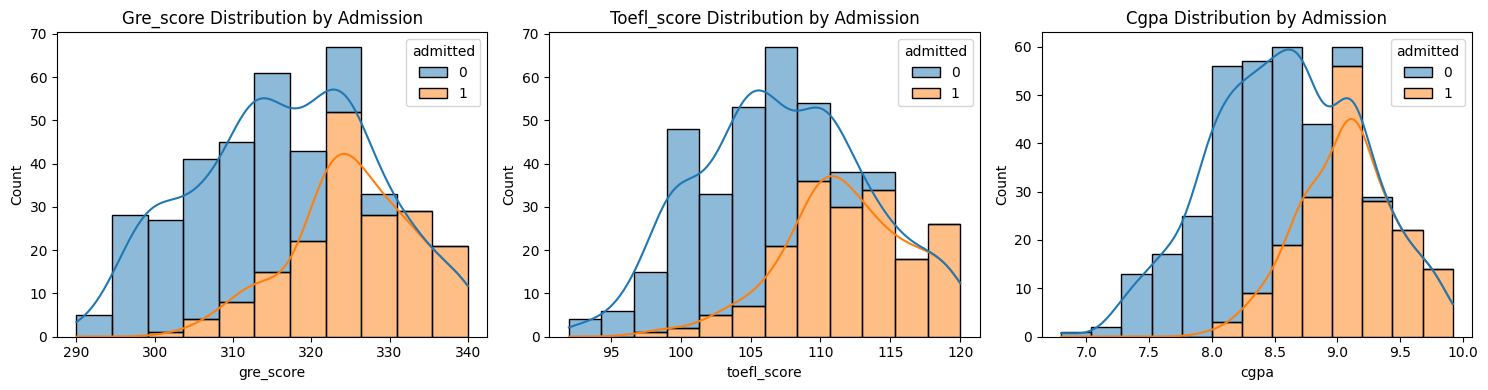

Accuracy: 0.93

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.91      0.93        47
           1       0.89      0.94      0.91        33

    accuracy                           0.93        80
   macro avg       0.92      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80



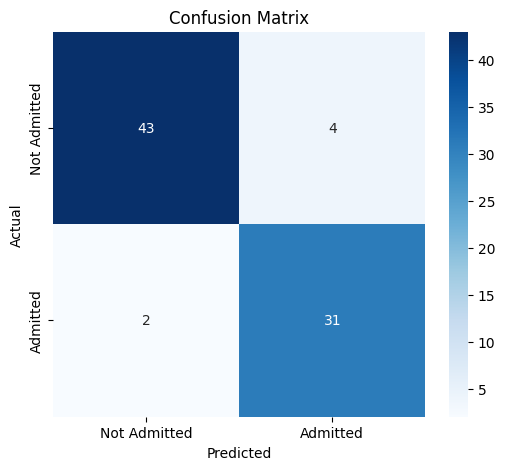


Admission prediction for new student (1 = admitted, 0 = not admitted): 1


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from google.colab import files
uploaded = files.upload()

# Load dataset (replace with your CSV file path)
df = pd.read_csv('Admission_Predict.csv (1).csv')


# Rename columns (remove spaces, lowercase)
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]

# Create binary target: admitted if chance_of_admit >= 0.75 else not
df['admitted'] = (df['chance_of_admit'] >= 0.75).astype(int)

# Show first few rows
print(df.head())

# Plot distributions of key features grouped by admission
features_to_plot = ['gre_score', 'toefl_score', 'cgpa']

plt.figure(figsize=(15, 4))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(1, 3, i)
    sns.histplot(data=df, x=feature, hue='admitted', kde=True, multiple="stack")
    plt.title(f'{feature.capitalize()} Distribution by Admission')
plt.tight_layout()
plt.show()

# Features and target
features = ['gre_score', 'toefl_score', 'university_rating', 'sop', 'lor', 'cgpa', 'research']
X = df[features]
y = df['admitted']

# Split dataset into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Admitted', 'Admitted'], yticklabels=['Not Admitted', 'Admitted'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Predict admission for a new student example
new_student = pd.DataFrame({
    'gre_score': [320],
    'toefl_score': [110],
    'university_rating': [4],
    'sop': [4.5],
    'lor': [4.0],
    'cgpa': [9.0],
    'research': [1]
})

pred = model.predict(new_student)
print("\nAdmission prediction for new student (1 = admitted, 0 = not admitted):", pred[0])